In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
import pandas as pd

era5 = pd.read_parquet("/Users/raman/Elnino/data/ERA5/era5_combined_1980_2026_landcheck.parquet")
era5.head()

,time,latitude,longitude,avg_iews,avg_inss,ttr,sst,t2m,msl,lsm,land_ocean
0,1980-01-01,-30.0,120.0,-0.157461,0.001843,-24030192.0,NaN,302.30980,100920.375,1.000000,land
1,1980-01-01,-30.0,122.0,-0.160635,0.015271,-24052208.0,NaN,301.18090,100998.125,0.899545,land
2,1980-01-01,-30.0,124.0,-0.098501,0.038526,-24364784.0,NaN,300.44263,101090.500,1.000000,land
3,1980-01-01,-30.0,126.0,-0.121206,0.080945,-24769008.0,NaN,300.43286,101106.625,1.000000,land
4,1980-01-01,-30.0,128.0,-0.126822,0.099744,-24659952.0,NaN,298.79420,101150.000,1.000000,land


In [4]:
import glob
import json
import os

BASE_DIR = "/Users/raman/Elnino"
DATA_DIR = os.path.join(BASE_DIR, "data")


def _iter_variable_blocks(obj):
    """Yield (name, attributes) for every 'variables' block in the metadata."""
    if not isinstance(obj, dict):
        return
    if "variables" in obj and isinstance(obj["variables"], dict):
        for name, spec in obj["variables"].items():
            attrs = spec.get("attributes", {}) if isinstance(spec, dict) else {}
            yield name, attrs
    for value in obj.values():
        if isinstance(value, dict) and "variables" in value:
            yield from _iter_variable_blocks(value)


def variable_units(metadata_path):
    """Return {variable: {"units": ..., "long_name": ...}} for a metadata file."""
    with open(metadata_path) as f:
        data = json.load(f)
    result = {}
    for name, attrs in _iter_variable_blocks(data):
        if name in result:
            continue
        result[name] = {
            "units": attrs.get("units", attrs.get("GRIB_units", "?")),
            "long_name": attrs.get("long_name", attrs.get("GRIB_name", "")),
        }
    return result


# Scan every metadata JSON under data/ and print the units of each variable.
for path in sorted(glob.glob(os.path.join(DATA_DIR, "**", "*metadata*.json"), recursive=True)):
    units = variable_units(path)
    if not units:
        continue
    print(os.path.relpath(path, BASE_DIR))
    width = max(len(v) for v in units)
    for var, info in sorted(units.items()):
        print(f"  {var:<{width}}  {info['units']:<10}  {info['long_name']}")
    print()


data/ERA5/combined_era5_metadata_2015-2025.json
  expver      ?           
  latitude    degrees_north  latitude
  longitude   degrees_east  longitude
  msl         Pa          Mean sea level pressure
  number      1           ensemble member numerical id
  sst         K           Sea surface temperature
  valid_time  ?           time

data/ERA5/era5_1980-1990_metadata.json
  avg_iews    N m**-2     Time-mean eastward turbulent surface stress
  avg_inss    N m**-2     Time-mean northward turbulent surface stress
  expver      ?           
  latitude    degrees_north  latitude
  longitude   degrees_east  longitude
  msl         Pa          Mean sea level pressure
  number      1           ensemble member numerical id
  sst         K           Sea surface temperature
  t2m         K           2 metre temperature
  ttr         J m**-2     Top net long-wave (thermal) radiation
  valid_time  ?           

data/ERA5/era5_1991-2000_metadata.json
  avg_iews    N m**-2     Time-mean eastward tu

In [5]:
#Compute monthly climatology over a fixed base period

mask = (era5["time"] >= "1980-01-01") & (era5["time"] <= "2010-12-31")
base = era5[mask]

In [6]:
print(base.count())

time          934092
latitude      934092
longitude     934092
avg_iews      934092
avg_inss      934092
ttr           934092
sst           851880
t2m           934092
msl           934092
lsm           934092
land_ocean     82212
dtype: int64


In [7]:
base.describe()

,latitude,longitude,avg_iews,avg_inss,ttr,sst,t2m,msl,lsm
count,934092.000000,934092.000000,934092.000000,934092.000000,9.340920e+05,851880.000000,934092.000000,934092.000000,934092.000000
mean,0.000000,200.000000,-0.044534,0.002853,-2.276660e+07,299.171235,297.503456,101317.103025,0.088793
std,17.888553,46.761833,0.053153,0.039436,2.089162e+06,3.029584,3.336150,380.791393,0.275066
min,-30.000000,120.000000,-1.214612,-0.881038,-2.784126e+07,283.845460,274.471920,100070.940000,0.000000
25%,-16.000000,160.000000,-0.073995,-0.016164,-2.440144e+07,297.360840,295.763670,101023.690000,0.000000
50%,0.000000,200.000000,-0.044487,0.002105,-2.309483e+07,299.948000,298.628170,101237.375000,0.000000
75%,16.000000,240.000000,-0.015020,0.022288,-2.146020e+07,301.562740,299.939200,101574.190000,0.000000
max,30.000000,280.000000,0.891299,0.666605,-1.242472e+07,305.301760,309.658450,103015.000000,1.000000


In [8]:
base[base['sst'] == base['sst'].max()]

,time,latitude,longitude,avg_iews,avg_inss,ttr,sst,t2m,msl,lsm,land_ocean
107398,1983-07-01,16.0,266.0,-0.008924,-0.029579,-18216208.0,305.30176,301.96875,101036.06,0.263047,NaN


In [9]:
base[base['sst'] == base['sst'].min()]

,time,latitude,longitude,avg_iews,avg_inss,ttr,sst,t2m,msl,lsm,land_ocean
125307,1984-02-01,26.0,120.0,-0.112928,-0.178235,-21990896.0,283.84546,282.2644,102225.81,0.006521,NaN


In [10]:
# Drop every row where sst is null (removes the whole row)
base = base.dropna(subset=['sst'])
print(base.count())

time          851880
latitude      851880
longitude     851880
avg_iews      851880
avg_inss      851880
ttr           851880
sst           851880
t2m           851880
msl           851880
lsm           851880
land_ocean         0
dtype: int64


In [11]:
print(base.head())

          time  latitude  longitude  avg_iews  avg_inss         ttr  \
17  1980-01-01     -30.0      154.0 -0.012442 -0.025622 -21739760.0   
18  1980-01-01     -30.0      156.0  0.005747 -0.044177 -21582064.0   
19  1980-01-01     -30.0      158.0  0.002329 -0.045093 -21224176.0   
20  1980-01-01     -30.0      160.0  0.003061 -0.048877 -21627376.0   
21  1980-01-01     -30.0      162.0 -0.010977 -0.043445 -22543088.0   

          sst        t2m         msl  lsm land_ocean  
17  299.03125  297.82740  100875.875  0.0        NaN  
18  299.02637  297.55590  100936.500  0.0        NaN  
19  298.17773  296.96997  101003.750  0.0        NaN  
20  297.43262  296.56177  101072.500  0.0        NaN  
21  297.04590  296.27270  101158.125  0.0        NaN  


In [12]:
base.describe()

,latitude,longitude,avg_iews,avg_inss,ttr,sst,t2m,msl,lsm
count,851880.000000,851880.000000,851880.000000,851880.000000,8.518800e+05,851880.000000,851880.000000,851880.000000,851880.000000
mean,0.616594,202.516157,-0.043662,0.001348,-2.277879e+07,299.171235,297.661571,101312.083084,0.004546
std,17.391588,44.526893,0.043442,0.032651,2.063255e+06,3.029584,2.937806,376.279163,0.036770
min,-30.000000,120.000000,-0.330963,-0.542657,-2.709011e+07,283.845460,280.315200,100070.940000,0.000000
25%,-14.000000,166.000000,-0.072281,-0.016156,-2.440829e+07,297.360840,296.029300,101021.690000,0.000000
50%,0.000000,202.000000,-0.044182,0.001494,-2.309813e+07,299.948000,298.700200,101227.000000,0.000000
75%,16.000000,240.000000,-0.015910,0.020051,-2.145853e+07,301.562740,299.932620,101564.750000,0.000000
max,30.000000,280.000000,0.311637,0.271814,-1.353955e+07,305.301760,304.466800,103015.000000,0.663967


In [13]:
# Ensure datetime and avoid modifying slice warnings
base = base.copy()
base["time"] = pd.to_datetime(base["time"])

group_cols = [base["time"].dt.month.rename("month"), "latitude", "longitude"]

# Mean and std climatology for all numeric variables at each (month, lat, lon)
climatology = base.groupby(group_cols).mean(numeric_only=True).reset_index()
climatology_std = base.groupby(group_cols).std(numeric_only=True).reset_index()

In [14]:
climatology[climatology['month'] == 1].describe()

,month,latitude,longitude,avg_iews,avg_inss,ttr,sst,t2m,msl,lsm
count,2290.0,2290.000000,2290.000000,2290.000000,2290.000000,2.290000e+03,2290.000000,2290.000000,2290.000000,2290.000000
mean,1.0,0.616594,202.516157,-0.042446,-0.011797,-2.279227e+07,298.986285,297.459132,101265.807369,0.004546
std,0.0,17.395376,44.536592,0.046319,0.029209,1.807798e+06,2.751674,2.822258,371.496889,0.036778
min,1.0,-30.000000,120.000000,-0.179420,-0.313495,-2.582965e+07,286.908897,283.563846,100580.542419,0.000000
25%,1.0,-14.000000,166.000000,-0.070759,-0.028328,-2.425172e+07,297.398470,296.043528,100959.601774,0.000000
50%,1.0,0.000000,202.000000,-0.047989,-0.011367,-2.300367e+07,299.488438,298.235721,101188.727984,0.000000
75%,1.0,16.000000,240.000000,-0.018127,0.007727,-2.171606e+07,301.128992,299.641705,101548.223710,0.000000
max,1.0,30.000000,280.000000,0.125973,0.069506,-1.684490e+07,303.714435,301.852279,102437.872742,0.663967


<Axes: xlabel='longitude', ylabel='latitude'>

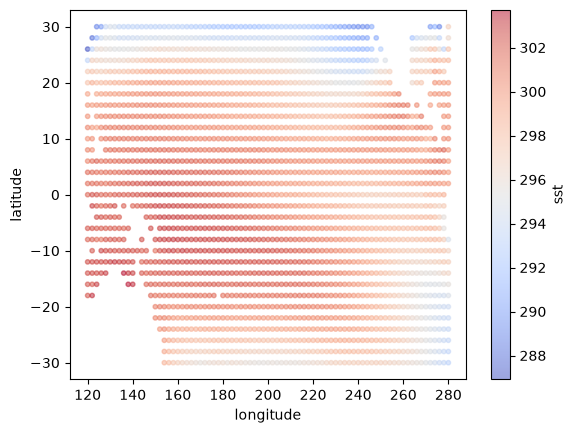

In [15]:
climatology[climatology['month'] == 1].plot(x="longitude", y="latitude", kind="scatter", c="sst", cmap="coolwarm", s=10, alpha=0.5)

Text(0, 0.5, 'Frequency')

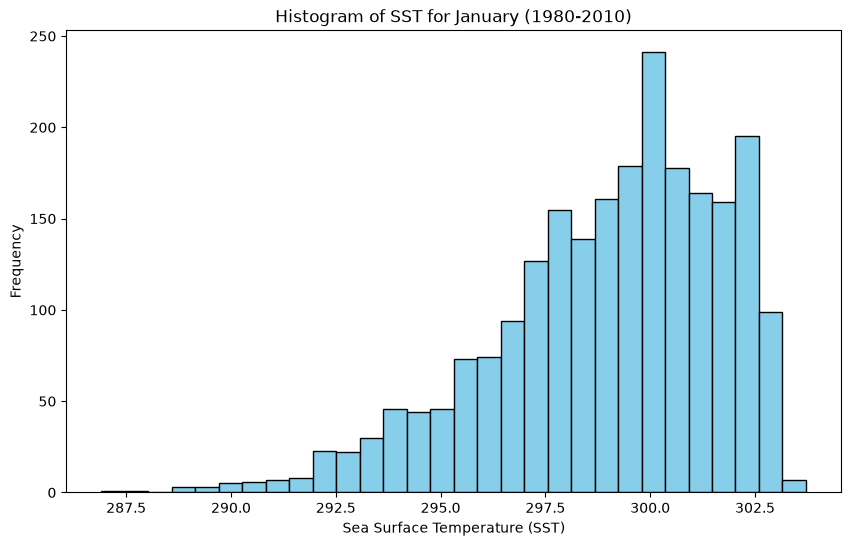

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(climatology[climatology['month'] == 1]['sst'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of SST for January (1980-2010)')
plt.xlabel('Sea Surface Temperature (SST)')
plt.ylabel('Frequency')

month
1     298.986285
2     299.062661
3     299.225708
4     299.367256
5     299.384496
6     299.341360
7     299.203607
8     299.095557
9     299.127169
10    299.135952
11    299.107611
12    299.017161
Name: sst, dtype: float64


([<matplotlib.axis.XTick at 0x11b76ed50>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12')])

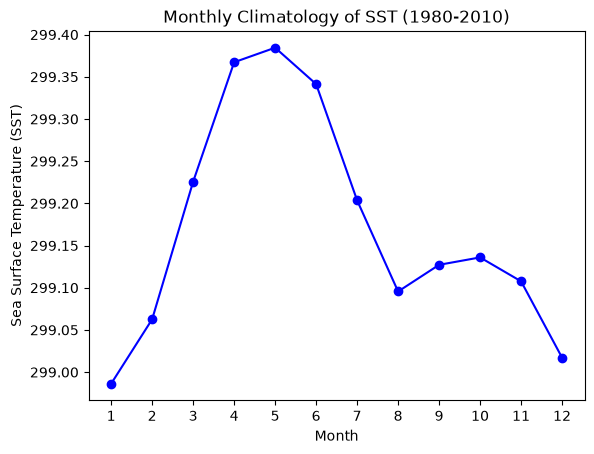

In [17]:
#timesereis plot 

monthly_mean = climatology.groupby('month')['sst'].mean()
print(monthly_mean)
plt.plot(monthly_mean.index, monthly_mean.values, color='blue', marker='o')
plt.title('Monthly Climatology of SST (1980-2010)')
plt.xlabel('Month')
plt.ylabel('Sea Surface Temperature (SST)')
plt.xticks(range(1, 13))

month
1     298.986285
2     299.062661
3     299.225708
4     299.367256
5     299.384496
6     299.341360
7     299.203607
8     299.095557
9     299.127169
10    299.135952
11    299.107611
12    299.017161
Name: sst, dtype: float64


([<matplotlib.axis.XTick at 0x11b844190>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12')])

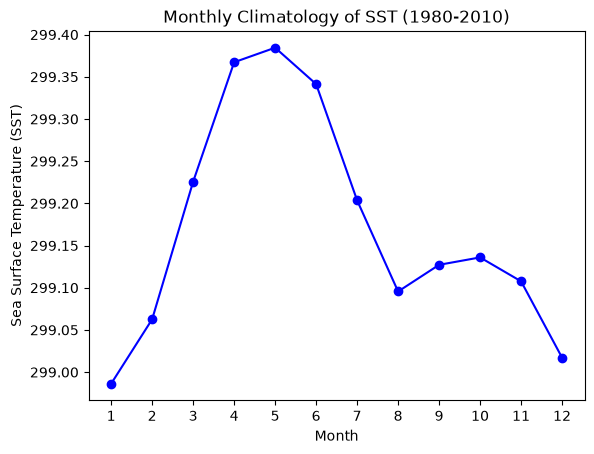

In [18]:
#timesereis plot 

monthly_mean = climatology.groupby('month')['sst'].mean()
print(monthly_mean)
plt.plot(monthly_mean.index, monthly_mean.values, color='blue', marker='o')
plt.title('Monthly Climatology of SST (1980-2010)')
plt.xlabel('Month')
plt.ylabel('Sea Surface Temperature (SST)')
plt.xticks(range(1, 13))

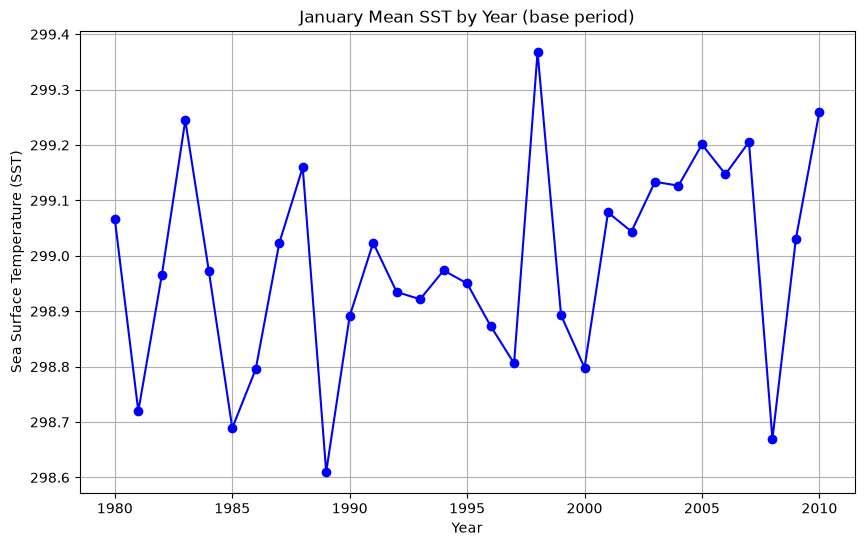

In [19]:
# Line plot of January SST from base across the years
jan = base[base["time"].dt.month == 1]
jan_yearly = jan.groupby(jan["time"].dt.year)["sst"].mean()

plt.figure(figsize=(10, 6))
plt.plot(jan_yearly.index, jan_yearly.values, color='blue', marker='o')
plt.title('January Mean SST by Year (base period)')
plt.xlabel('Year')
plt.ylabel('Sea Surface Temperature (SST)')
plt.grid(True)

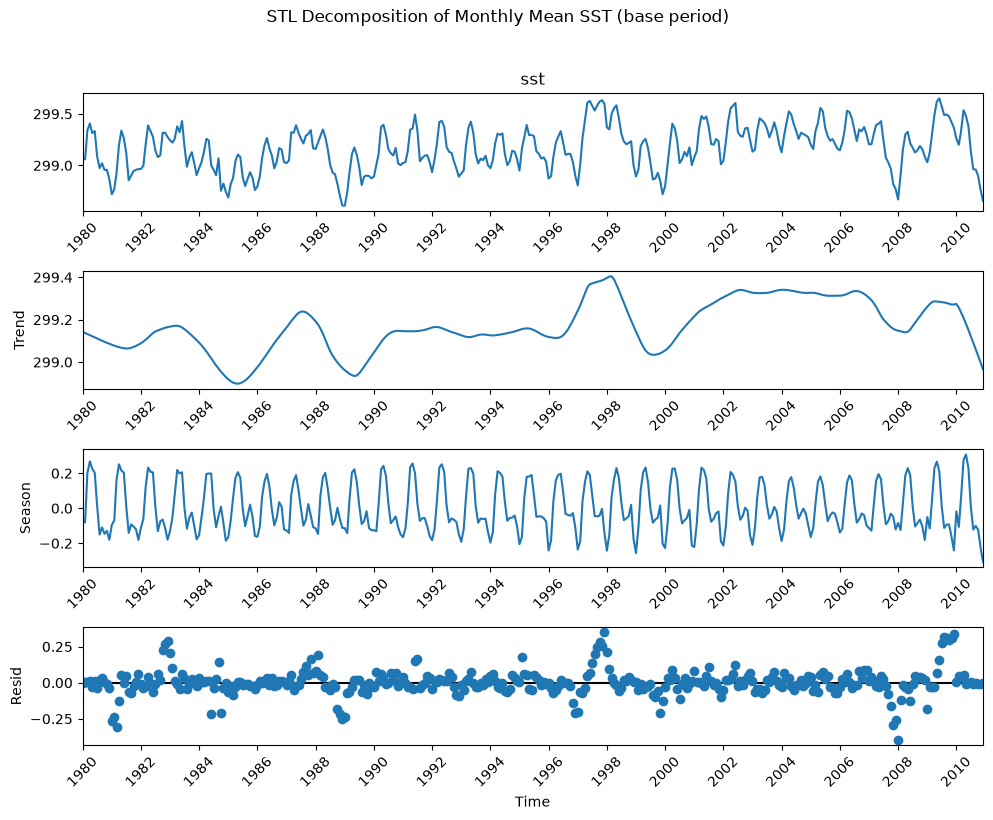

Trend variance share:    30.21%
Seasonal variance share: 39.35%
Residual variance share: 18.00%


In [20]:
# Seasonal decomposition of the monthly-mean SST time series
from statsmodels.tsa.seasonal import STL

# Build a regular monthly series (area-mean SST per month)
monthly_sst = (
    base.groupby(base["time"].dt.to_period("M"))["sst"]
    .mean()
)
monthly_sst.index = monthly_sst.index.to_timestamp()
monthly_sst = monthly_sst.asfreq("MS")  # ensure a regular monthly frequency

# STL decomposition (period = 12 months)
stl = STL(monthly_sst, period=12, robust=True)
result = stl.fit()

fig = result.plot()
fig.set_size_inches(10, 8)
fig.suptitle("STL Decomposition of Monthly Mean SST (base period)", y=1.02)

# Show the time line on the x-axis of every subplot
import matplotlib.dates as mdates
for ax in fig.axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelbottom=True, rotation=45)
fig.axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

# How much variability is seasonal vs. trend vs. residual
var_total = monthly_sst.var()
print(f"Trend variance share:    {result.trend.var()    / var_total:.2%}")
print(f"Seasonal variance share: {result.seasonal.var() / var_total:.2%}")
print(f"Residual variance share: {result.resid.var()    / var_total:.2%}")

In [26]:
df_sa = pd.read_csv("/Users/raman/Elnino/data/ERA5_single_levels_southasia/era5_single_levels_southasia_1980_2025_landcheck.csv")

In [22]:
df_sa.isnull().sum()

time                       0
 latitude                  0
 longitude                 0
 sst                       0
 t2m                       0
 msl                       0
 avg_iews                  0
 avg_inss                  0
 ttr                       0
 lsm                       0
 land_ocean                0
dtype: int64

In [23]:
# The land SST "nulls" were stored as blank strings, and columns were space-padded,
# so the column loaded as str and isnull() saw no NaN. Reload cleanly:
df_sa = pd.read_csv(
    "/Users/raman/Elnino/data/ERA5_single_levels_southasia/era5_single_levels_southasia_1980_2025_landcheck.csv",
    skipinitialspace=True,        # drop the space after each comma
    na_values=["", " "],          # treat blank fields as NaN
)
df_sa.columns = df_sa.columns.str.strip()   # strip padding from header names

# Coerce numeric columns (blanks -> NaN, text -> number)
num_cols = ["latitude", "longitude", "sst", "t2m", "msl",
            "avg_iews", "avg_inss", "ttr", "lsm"]
df_sa[num_cols] = df_sa[num_cols].apply(pd.to_numeric, errors="coerce")

print("sst dtype:", df_sa["sst"].dtype)
print("\nnulls per column:")
print(df_sa.isnull().sum())

sst dtype: float64

nulls per column:
time               0
latitude           0
longitude          0
sst           121992
t2m                0
msl                0
avg_iews           0
avg_inss           0
ttr                0
lsm                0
land_ocean     86664
dtype: int64


In [24]:
df_sa.describe()

,latitude,longitude,sst,t2m,msl,avg_iews,avg_inss,ttr,lsm
count,208656.00000,208656.00000,86664.000000,208656.000000,208656.000000,208656.000000,208656.000000,2.086560e+05,208656.000000
mean,22.00000,80.00000,301.364794,292.540790,101139.467153,0.060809,0.025123,-2.168516e+07,0.587197
std,10.37628,12.11063,2.281121,13.106046,588.216720,0.135493,0.112429,3.210414e+06,0.477327
min,5.00000,60.00000,273.149170,239.813350,99171.440000,-0.995526,-1.139716,-2.972101e+07,0.000000
25%,13.00000,70.00000,300.890380,287.380930,100814.423750,-0.009898,-0.019554,-2.454268e+07,0.000000
50%,22.00000,80.00000,301.709960,299.259950,101089.810000,0.024960,0.003089,-2.174490e+07,0.977177
75%,31.00000,90.00000,302.377440,300.763430,101452.440000,0.090612,0.051051,-1.896128e+07,0.999781
max,39.00000,100.00000,305.074700,312.747560,103795.000000,1.942980,1.855141,-1.363482e+07,1.000000


In [25]:
df_sa.dtypes

time              str
latitude      float64
longitude     float64
sst           float64
t2m           float64
msl           float64
avg_iews      float64
avg_inss      float64
ttr           float64
lsm           float64
land_ocean        str
dtype: object